In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("45-medical_cost.csv")

In [3]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.drop('Id', axis=1, inplace=True)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


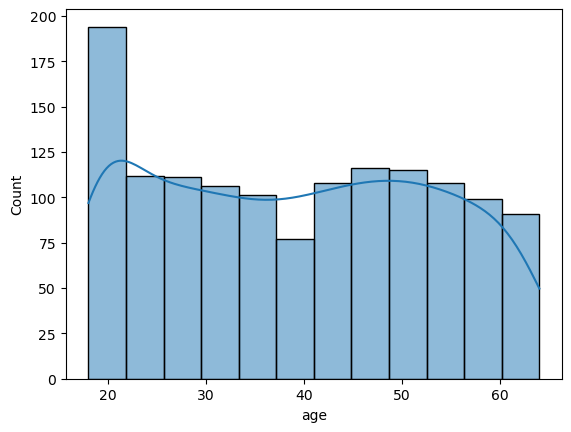

In [6]:
sns.histplot(df, x = 'age', kde=True)
plt.show()

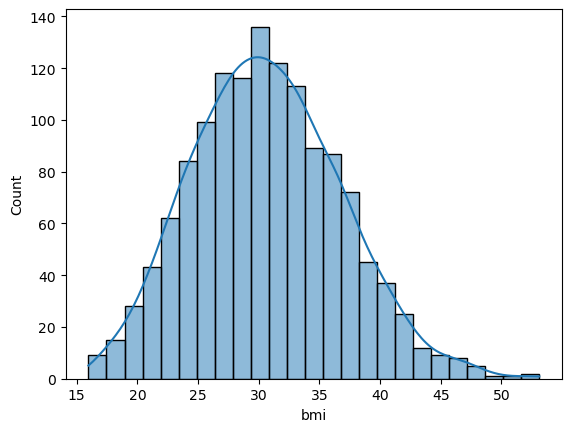

In [7]:
sns.histplot(df, x = 'bmi', kde=True)
plt.show()

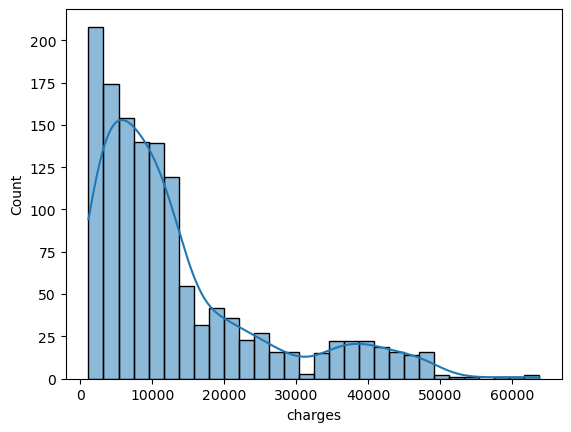

In [8]:
sns.histplot(df, x = 'charges', kde=True)
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
len(df[df['charges'] > 50000])

7

In [16]:
df = df[df['charges'] < 50000]

In [18]:
df.shape

(1331, 7)

In [19]:
df.describe()

,age,bmi,children,charges
count,1331.000000,1331.000000,1331.00000,1331.000000
mean,39.185575,30.633017,1.09692,13036.775677
std,14.058021,6.088782,1.20603,11699.360324
min,18.000000,15.960000,0.00000,1121.873900
25%,26.000000,26.220000,0.00000,4719.630300
50%,39.000000,30.305000,1.00000,9301.893550
75%,51.000000,34.600000,2.00000,16359.170275
max,64.000000,53.130000,5.00000,49577.662400


In [20]:
df['sex'] = df['sex'].replace({
    'male' : 1,
    'female' : 0
}
)

df['smoker'] = df['smoker'].replace({
    'yes' : 1,
    'no' : 0
}
)

C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_11508\959865429.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({
C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_11508\959865429.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({


In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [22]:
df.sex.value_counts()

sex
1    672
0    659
Name: count, dtype: int64

In [23]:
df.smoker.value_counts()

smoker
0    1064
1     267
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1331 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1331 non-null   int64  
 1   sex       1331 non-null   int64  
 2   bmi       1331 non-null   float64
 3   children  1331 non-null   int64  
 4   smoker    1331 non-null   int64  
 5   region    1331 non-null   object 
 6   charges   1331 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 83.2+ KB


In [26]:
df['region'].value_counts()

region
southeast    362
southwest    323
northwest    323
northeast    323
Name: count, dtype: int64

In [33]:
onehot_columns = ['region']

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [35]:
transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), onehot_columns)
    ],
    remainder='passthrough'
)

In [36]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['charges'])
y = df['charges']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)

In [38]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [40]:
X_train

array([[ 1.   ,  0.   ,  0.   , ..., 36.765,  2.   ,  0.   ],
       [ 0.   ,  1.   ,  0.   , ..., 27.06 ,  0.   ,  1.   ],
       [ 0.   ,  1.   ,  0.   , ..., 53.13 ,  0.   ,  0.   ],
       ...,
       [ 0.   ,  1.   ,  0.   , ..., 46.53 ,  1.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ..., 19.   ,  3.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ..., 28.5  ,  0.   ,  0.   ]])

In [41]:
new_columns = transformer.get_feature_names_out()

In [42]:
X_train = pd.DataFrame(data=X_train, columns=new_columns)
X_test = pd.DataFrame(data=X_test, columns=new_columns)

In [43]:
X_train.head()

,onehot__region_northwest,onehot__region_southeast,onehot__region_southwest,remainder__age,remainder__sex,remainder__bmi,remainder__children,remainder__smoker
0,1.0,0.0,0.0,52.0,1.0,36.765,2.0,0.0
1,0.0,1.0,0.0,26.0,1.0,27.060,0.0,1.0
2,0.0,1.0,0.0,18.0,1.0,53.130,0.0,0.0
3,0.0,0.0,1.0,38.0,0.0,27.600,0.0,0.0
4,0.0,1.0,0.0,42.0,1.0,24.640,0.0,1.0


In [44]:
X_test.head()

,onehot__region_northwest,onehot__region_southeast,onehot__region_southwest,remainder__age,remainder__sex,remainder__bmi,remainder__children,remainder__smoker
0,0.0,1.0,0.0,62.0,1.0,31.460,1.0,0.0
1,0.0,0.0,1.0,19.0,0.0,18.600,0.0,0.0
2,0.0,1.0,0.0,62.0,1.0,38.830,0.0,0.0
3,1.0,0.0,0.0,45.0,1.0,21.375,0.0,0.0
4,0.0,0.0,1.0,34.0,0.0,38.000,3.0,0.0


In [45]:
from lightgbm import LGBMRegressor

In [46]:
lgb = LGBMRegressor()
lgb.fit(X_train, y_train)
y_pred = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 1064, number of used features: 8
[LightGBM] [Info] Start training from score 13149.265017


In [47]:
from sklearn.metrics import r2_score

In [48]:
print(r2_score(y_pred, y_test))

0.8581168253366132


In [49]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html
params = {
    'num_leaves' : [15, 31, 63, 127],
    'max_depth' : [None, 3, 5, 10, 20, 30],
    'learning_rate' : [0.1, 0.05, 1],
    'n_estimators' : [30, 50, 100, 200, 300],
    "min_child_samples" : [10,20,30],
    "subsample" : [0.6, 0.8, 1.0],
    "colsample_bytree" : [0.6, 0.8, 1.0],
    "reg_alpha" : [0, 0.5, 1.0],
    "reg_lambda" : [0, 0.5, 1.0]
}

In [50]:
from sklearn.model_selection import RandomizedSearchCV

In [51]:
import warnings
warnings.filterwarnings('ignore')

In [52]:
random = RandomizedSearchCV(estimator=LGBMRegressor(), param_distributions=params, cv=5, verbose=1, n_jobs=-1, scoring='r2')

In [53]:
random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 1064, number of used features: 8
[LightGBM] [Info] Start training from score 13149.265017
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

RandomizedSearchCV(cv=5, estimator=LGBMRegressor(), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.1, 0.05, 1],
                                        'max_depth': [None, 3, 5, 10, 20, 30],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [30, 50, 100, 200, 300],
                                        'num_leaves': [15, 31, 63, 127],
                                        'reg_alpha': [0, 0.5, 1.0],
                                        'reg_lambda': [0, 0.5, 1.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='r2', verbose=1)

In [54]:
y_pred = random.predict(X_test)

In [55]:
print(r2_score(y_pred, y_test))

0.8448026019772066


In [56]:
random.best_params_

{'subsample': 1.0,
 'reg_lambda': 0.5,
 'reg_alpha': 0,
 'num_leaves': 127,
 'n_estimators': 300,
 'min_child_samples': 20,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.6}

- Şimdi bağımlı değişkenimiz olan `charges` değişkenine transform yaparak dağılımını düzelteceğiz.

In [57]:
from scipy.stats import boxcox

In [58]:
y_train_transformed, lambda_y = boxcox(y_train)

In [59]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 1064, number of used features: 8
[LightGBM] [Info] Start training from score 12.340882


LGBMRegressor()

In [60]:
# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [63]:
y_pred_transformed= model.predict(X_test)
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [64]:
print(r2_score(y_test, y_pred_original))

0.8821613737468764
